# Aula 12: Aprendizado de Máquina - Regressão e o Projeto Final

Chegamos à nossa última aula de conteúdo novo. Na aula passada, ensinamos o computador a ser um _juiz_ e a **classificar** Pokémon (Lendário ou Não-Lendário). Hoje, vamos ensiná-lo a **prever números**. 

# 📋 Revisão:
- **O que é Aprendizado de Máquina (AM)?** É a área da computação que ensina o computador a tomar decisões _aprendendo com exemplos (dados)_, em vez de seguirmos regras (`if/else`) que um programador escreveu.
- **Divisão de Desenvolvimento e Teste** Para saber se nosso modelo _aprendeu_ de verdade (e não apenas _decorou_), nós separamos nossos dados.
	- **Conjunto de Desenvolvimento:** 
		- **Dados de Treino:** Usado para ajustar o modelo. É como assistir uma aula.
		- **Dados de Validação:** Utilizamos um conjunto que não foi utilizado no treino para avaliar a qualidade esperada do modelo. É como fazer um simulado ou lista de exercícios.        
    - **Conjunto de Teste:** Os que escondemos do modelo e usamos como a "prova final" para ver se ele realmente aprendeu.     
# 2. O Desafio: Prevendo o Ataque de um Pokémon
Na aula passada, resolvemos a primeira tarefa do Professor Carvalho (Classificação). Hoje, vamos resolver a segunda:

> **"Você consegue prever o poder de Ataque de um Pokémon olhando apenas sua Defesa e HP?"**

Este é um problema de **Regressão**, porque a nossa resposta (o `Ataque`) não é uma categoria "Lendário" ou "Não Lendário", mas sim um **número contínuo** (pode ser 50, 82, 134, etc.).

Vamos preparar nosso ambiente.

In [1]:
# Instale o scikit-learn se ainda não o fez
# pip install scikit-learn matplotlib seaborn pandas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Carregar nossos dados
df = pd.read_csv('https://raw.githubusercontent.com/Assaoka/Decolar--Introducao_a_Ciencia_de_Dados/refs/heads/main/pokemon.csv')

# Limpar alguns dados que podem quebrar o modelo
df = df[['Health', 'Attack', 'Defense']]
df.sample(5)

,Health,Attack,Defense
205,100,100,100
376,50,85,85
377,50,105,125
705,70,135,105
1040,100,130,100


# 3. O que é X e Y?
Em Aprendizado de Máquina, tudo se resume a `X` e `Y`. Nosso objetivo é descobrir um conjunto de operações sobre X (características de entrada, nesse caso `HP` e `Defesa`) que melhor aproxima o valor de Y (característica alvo, no caso `Ataque`).

In [21]:
# Definir X e Y
features = ['Health', 'Defense']
target = 'Attack'

X = df[features]
y = df[target]

X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, 
    test_size=0.1,
    random_state=42 
)

X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev,
    test_size=0.2,
    random_state=42
)

print(f"Total de dados: {len(X)}")
print(f"Dados de Treino: {len(X_train)}")
print(f"Dados de Validação: {len(X_val)}")
print(f"Dados de Teste: {len(X_test)}")

Total de dados: 1184
Dados de Treino: 852
Dados de Validação: 213
Dados de Teste: 119


Por exemplo, suponha que temos os dados X e Y:

|  X  |  Y  |
| :-: | :-: |
|  1  |  4  |
|  2  |  7  |
|  5  | 16  |

Observe que esses dados são gerados por $y = 3*x + 1$

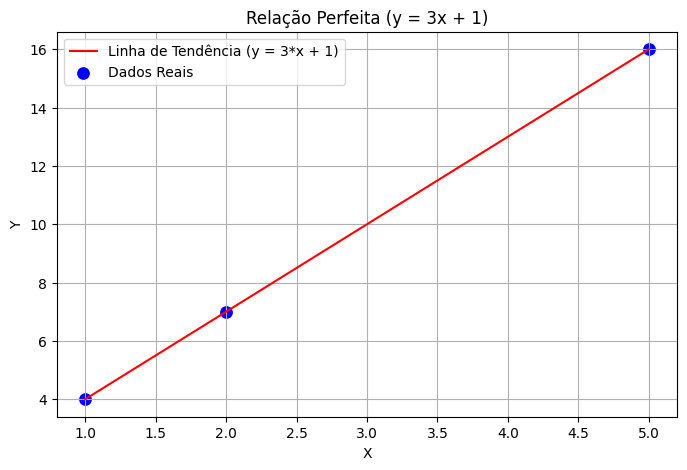

In [22]:
x = np.array([1, 2, 5])

def modelo(x):
    return 3*x + 1

y = modelo(x)

# Gráfico de dispersão com a linha de tendência.
plt.figure(figsize=(8, 5))
sns.lineplot(x=x, y=y, color='red', label='Linha de Tendência (y = 3*x + 1)')
sns.scatterplot(x=x, y=y, s=100, label='Dados Reais', color='blue')
plt.title('Relação Perfeita (y = 3x + 1)')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.legend()
plt.show()

Essa equação que utilizamos é a equação da reta, que é:

$$y = a*x + b$$

O objetivo da regressão linear é encontrar os números a e b que minimiza o erro (distância do número previsto para o real) no nosso conjunto de treinamento.

# 📈 4. Regressão Linear com 1 Variável
Antes de usar `HP` e `Defesa` juntos, vamos simplificar. E se usássemos _apenas_ a `Defesa` para prever o `Ataque`?

Vamos ver a relação entre eles no nosso gráfico:

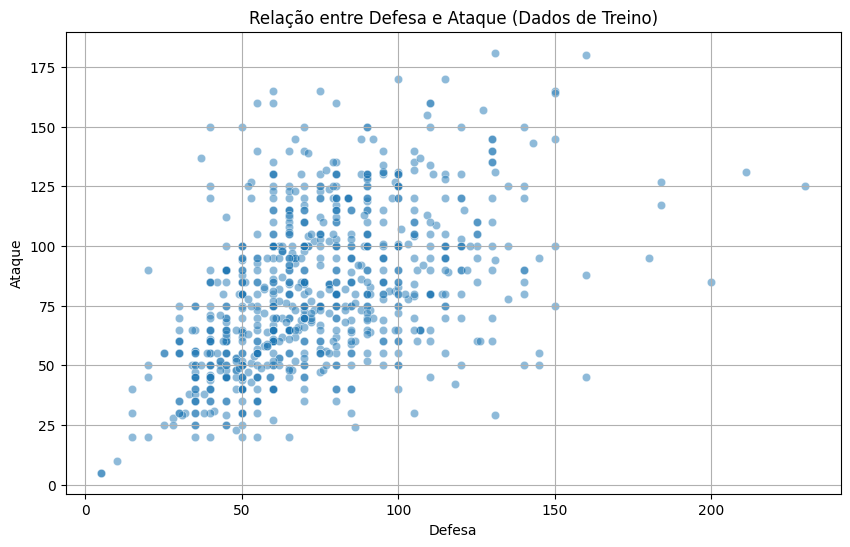

In [23]:
# Plotar Defesa vs Ataque
plt.figure(figsize=(10, 6))
sns.scatterplot(data=X_train, x='Defense', y=y_train, alpha=0.5)
plt.title('Relação entre Defesa e Ataque (Dados de Treino)')
plt.xlabel('Defesa')
plt.ylabel('Ataque')
plt.grid(True)
plt.show()

Olhando o gráfico, parece que existe uma _tendência_: Pokémon com mais defesa _geralmente_ têm um ataque um pouco maior.

Nós queremos achar os melhores valores para $a$ e $b$ para a seguinte reta:

$$Ataque = a * Defesa + b$$

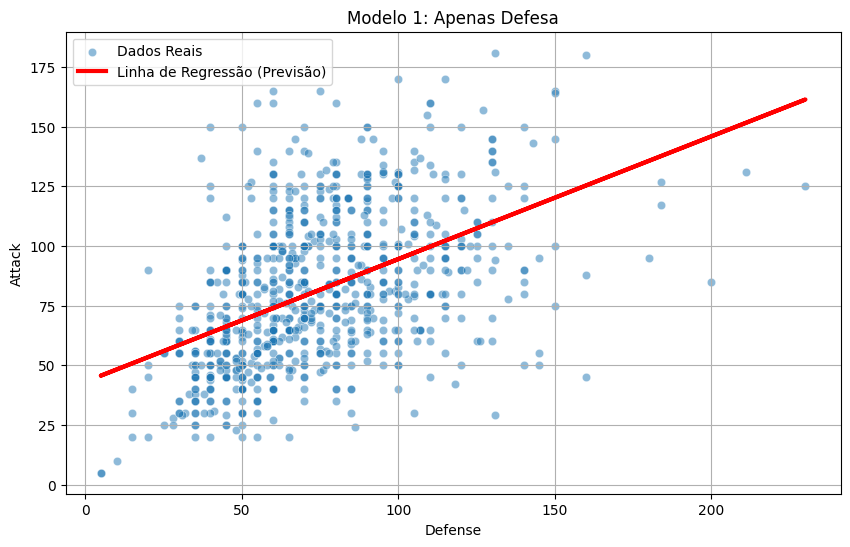

In [33]:
# --- Modelo 1: Apenas Defesa ---
# 1. Preparar os dados (só com Defesa)
X_train_def = X_train[['Defense']]
X_val_def = X_val[['Defense']]
X_test_def = X_test[['Defense']]

# 2. Criar e Treinar o modelo
modelo_1 = LinearRegression()
modelo_1.fit(X_train_def, y_train)

# 3. Fazer previsões
y_pred_1 = modelo_1.predict(X_train_def)

# 4. Ver a "linha" que o modelo encontrou
plt.figure(figsize=(10, 6))
sns.scatterplot(data=X_train_def, x='Defense', y=y_train, alpha=0.5, label='Dados Reais')
plt.plot(X_train_def, y_pred_1, color='red', linewidth=3, label='Linha de Regressão (Previsão)')
plt.title('Modelo 1: Apenas Defesa')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
a = modelo_1.coef_[0]
b = modelo_1.intercept_
print(f"Y = Modelo(X) = {a:.2f} * x + {b:.2f}")

Y = Modelo(X) = 0.51 * x + 43.11


# 💯 5. Como saber se o modelo é bom?
Na Classificação, usamos Acurácia, Precisão, Recall e F1-Score. Em Regressão, o mais comum é o **RMSE (Raiz do Erro Quadrático Médio)**.

O RMSE nos diz, em média, _quantos pontos_ a nossa previsão errou. Se o `Ataque` real era 100 e o modelo previu 90, o erro foi 10. O RMSE é uma média de todos esses erros (penalizando erros maiores). **Quanto menor o RMSE, melhor o modelo.**

In [37]:
# Calcular o erro do Modelo 1
y_pred_1 = modelo_1.predict(X_val_def)
rmse_1 = np.sqrt(mean_squared_error(y_val, y_pred_1))
print(f"Erro Médio do Modelo 1 (RMSE): {rmse_1:.2f} pontos de Ataque")

Erro Médio do Modelo 1 (RMSE): 26.21 pontos de Ataque


Isso significa que, ao usar _apenas_ a Defesa, nosso modelo erra a previsão de Ataque por cerca de `26` pontos.

# 💪 6. Melhorando o Modelo
Nossa tarefa original era usar `HP` _e_ `Defesa`. Agora a equação não é mais uma linha, é um _plano_ 3D: 
$$Ataque = a \cdot Defesa + b \cdot HP + c$$
Mas para o `sklearn`, o código é quase o mesmo!


In [ ]:
# --- Modelo 2: Defesa + HP ---

# 1. Preparar os dados (já estão em X_train e X_test)
# 2. Criar e Treinar o modelo
modelo_2 = LinearRegression()
modelo_2.fit(X_train, y_train) # X_train tem 'Defense' e 'Health'

# 3. Fazer previsões
y_pred_2 = modelo_2.predict(X_val)

# 4. Calcular o erro do Modelo 2
rmse_2 = np.sqrt(mean_squared_error(y_val, y_pred_2))

print(f"Erro Médio do Modelo 1 (só Defesa): {rmse_1:.2f}")
print(f"Erro Médio do Modelo 2 (Defesa + HP): {rmse_2:.2f}")

Erro Médio do Modelo 1 (só Defesa): 26.21
Erro Médio do Modelo 2 (Defesa + HP): 23.73


In [43]:
a = modelo_2.coef_[0]
b = modelo_2.coef_[1]
c = modelo_2.intercept_
print(f"Ataque = modelo(Defesa, HP) = {a:.2f} * Defesa + {b:.2f} * HP + {c:.2f}")

Ataque = modelo(Defesa, HP) = 0.39 * Defesa + 0.41 * HP + 23.20


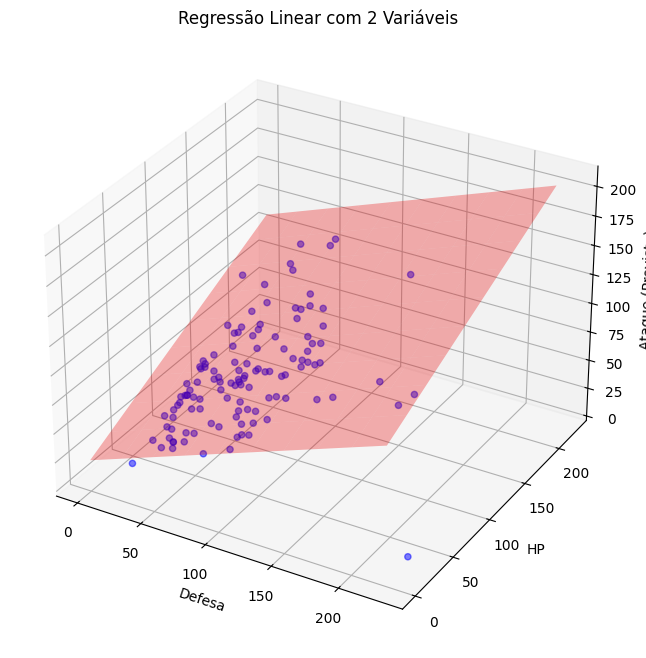

In [44]:
# Plotar o plano 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Pontos reais
ax.scatter(X_test['Defense'], X_test['Health'], y_test, c='blue', alpha=0.5, label='Dados Reais (Teste)')

# Criando a superfície do plano
xx, yy = np.meshgrid(range(0, 250, 25), range(0, 250, 25))
zz = modelo_2.coef_[1] * xx + modelo_2.coef_[0] * yy + modelo_2.intercept_
ax.plot_surface(xx, yy, zz, alpha=0.3, color='red', label='Plano de Regressão')

ax.set_xlabel('Defesa')
ax.set_ylabel('HP')
ax.set_zlabel('Ataque (Previsto)')
plt.title("Regressão Linear com 2 Variáveis")
plt.show()

Com base no erro de validação selecionamos o modelo 2 como nosso modelo final. O erro dele no conjunto de teste foi:

In [46]:
y_pred = modelo_2.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")

RMSE: 29.30


# 🏆 O Projeto Final!
O objetivo é vocês criarem um projeto aplicando os conteúdos apresentados:
1. **Encontrar um Dataset:** Vocês vão procurar seus próprios dados no [Kaggle](kaggle.com) (vamos aprender como agora!). 
2. **Análise de Dados:** Fazer a limpeza, manipulação e criar os gráficos que aprendemos para encontrar padrões.
3. **App Interativo:** Criar uma interface no Streamlit para exibir suas análises.
4. **Modelo de AM:** Treinar um modelo (Classificação ou Regressão) para fazer previsões sobre seus dados.